In [ ]:
# Setup imports & load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
df = pd.read_csv('data/raw_transactions.csv', na_values=['Nan', ''])


# Section 13: 50 Senior Pandas Interview Questions & Interactive Solutions
This section features 50 real-world, high-level interview questions executed against your dataset columns.

### Q1: How do you perform a deep memory profile check on our transactions dataset, showing memory in MB for string columns?

In [51]:
# Solution:
mem_bytes = df.memory_usage(deep=True)
for col in df.columns:
    print(f"Col '{col}': {mem_bytes[col] / 1e6:.4f} MB")

Col 'transaction_id': 0.5700 MB
Col 'customer_id': 0.5500 MB
Col 'transaction_amount': 0.0800 MB
Col 'account_age_months': 0.0800 MB
Col 'transaction_date': 0.6104 MB
Col 'region': 0.5354 MB


### Q2: How do you downcast the numeric type of account_age_months to save memory using pd.to_numeric()?

In [52]:
# Solution:
before_type = df['account_age_months'].dtype
df['account_age_months'] = pd.to_numeric(df['account_age_months'], downcast='unsigned')
after_type = df['account_age_months'].dtype
print(f"Type changed from {before_type} to {after_type}")

Type changed from int64 to uint8


### Q3: How do you convert the geographical 'region' column into a categorical type and check the compression ratio?

In [53]:
before_size = df['region'].memory_usage(deep=True)
# Solution:
df_optimized = df.copy()
df_optimized['region'] = df_optimized['region'].astype('category')
after_size = df_optimized['region'].memory_usage(deep=True)
print(f"Before: {before_size} bytes, After: {after_size} bytes")
print(f"Savings: {(1 - after_size/before_size)*100:.2f}%")

Before: 535575 bytes, After: 11082 bytes
Savings: 97.93%


### Q4: How do you stream/process chunks of data/raw_transactions.csv to compute the sum of transaction_amount without loading it fully into memory?

In [54]:
# Solution:
total_sum = 0
for chunk in pd.read_csv('data/raw_transactions.csv', chunksize=2000):
    total_sum += pd.to_numeric(chunk['transaction_amount'], errors='coerce').sum()
print("Total sum of transaction_amount via chunks:", total_sum)

Total sum of transaction_amount via chunks: 7286293.42


### Q5: Z-Score normalization: How do you subtract the group region mean and divide by group region std within groupby without merging?

In [55]:
# Solution:
grp_mean = df.groupby('region')['transaction_amount'].transform('mean')
grp_std = df.groupby('region')['transaction_amount'].transform('std')
df['amount_z_score'] = (df['transaction_amount'] - grp_mean) / grp_std
print(df[['region', 'transaction_amount', 'amount_z_score']].head(5))

  region  transaction_amount  amount_z_score
0  North                 NaN             NaN
1  North              931.17        0.357856
2  South              932.88        0.420002
3   West              339.48       -0.932143
4  North              100.39       -1.570856


### Q6: How do you filter out entire regions that have an aggregate transaction volume below a threshold (e.g. 100,000)?

In [56]:
# Solution:
result = df.groupby('region').filter(lambda g: g['transaction_amount'].sum() >= 100000)
print("Remaining regions:", result['region'].unique())

Remaining regions: ['North' 'South' 'West' 'East']


### Q7: How do you retrieve the top 3 highest-value transactions for each region using a custom apply?

In [57]:
# Solution:
result = df.groupby('region', group_keys=False).apply(lambda g: g.nlargest(3, 'transaction_amount'))
print(result[['region', 'transaction_id', 'transaction_amount']])

       region transaction_id  transaction_amount
9384    East        TX108076             1487.22
9581    East        TX105596             1477.86
1034    East        TX108767             1467.02
3153   North        TX105486             1435.45
2788   North        TX108813             1409.95
8883   North        TX108351             1395.03
6784   South        TX109389             1489.00
1020   South        TX107458             1453.14
8199   South        TX104163             1445.27
1740    West        TX105630             1446.51
2206    West        TX106851             1365.70
6853    West        TX104170             1343.21
1685     East       TX104220             1499.74
2576     East       TX105488             1499.64
1056     East       TX107228             1499.36
4996    North       TX103565             1499.19
9672    North       TX103714             1499.04
3985    North       TX102846             1498.88
4457    South       TX107105             1499.83
4455    South       

C:\Users\DELL\AppData\Local\Temp\ipykernel_9452\1441121769.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('region', group_keys=False).apply(lambda g: g.nlargest(3, 'transaction_amount'))


### Q8: How do you compute a 7-day rolling average of transaction amounts after setting transaction_date as index?

In [58]:
df_roll = df.copy()
df_roll['transaction_date'] = pd.to_datetime(df_roll['transaction_date'], format='mixed')
df_roll = df_roll.set_index('transaction_date').sort_index()
# Solution:
rolling_avgs = df_roll['transaction_amount'].rolling('7D').mean()
print(rolling_avgs.head(15))

transaction_date
2025-01-01 00:00:00    1133.710000
2025-01-01 00:00:00     993.045000
2025-01-01 00:00:00     879.043333
2025-01-01 00:00:00    1031.000000
2025-01-01 00:00:00     896.048000
2025-01-01 00:00:00     966.108333
2025-01-01 00:00:00    1035.635714
2025-01-01 00:00:00    1058.183750
2025-01-01 03:31:09    1066.297778
2025-01-01 03:43:42    1033.165000
2025-01-02 00:00:00     978.714545
2025-01-02 00:00:00     961.545000
2025-01-02 00:00:00     946.354615
2025-01-02 00:00:00     890.072143
2025-01-02 00:00:00     920.419333
Name: transaction_amount, dtype: float64


### Q9: How do you compute the expanding standard deviation of transaction amounts chronologically?

In [59]:
df_exp = df.copy()
df_exp['transaction_date'] = pd.to_datetime(df_exp['transaction_date'], format='mixed')
df_exp = df_exp.sort_values('transaction_date')
# Solution:
expanding_std = df_exp['transaction_amount'].expanding().std()
print(expanding_std.head(10))

4999           NaN
6843    198.930351
6115    242.437172
8739    362.694319
8000    435.569269
505     425.707849
8510    429.954696
4880    403.137237
6210    377.885187
9420    371.360562
Name: transaction_amount, dtype: float64


### Q10: How do you smooth out transaction trends using Exponentially Weighted Moving Average (EWMA) with span=30?

In [60]:
df_ewm = df.copy()
df_ewm['transaction_date'] = pd.to_datetime(df_ewm['transaction_date'], format='mixed')
df_ewm = df_ewm.sort_values('transaction_date')
# Solution:
ewma_vals = df_ewm['transaction_amount'].ewm(span=30).mean()
print(ewma_vals.head(10))

4999    1133.710000
6843     988.356167
6115     868.341048
8739    1038.768314
8000     883.476598
505      968.173198
8510    1051.992561
4880    1077.586733
6210    1085.252335
9420    1038.820428
Name: transaction_amount, dtype: float64


### Q11: How do you calculate the month-over-month percentage change in total transaction amounts?

In [61]:
df_time = df.copy()
df_time['transaction_date'] = pd.to_datetime(df_time['transaction_date'], format='mixed')
df_time = df_time.set_index('transaction_date').sort_index()
# Solution:
monthly_totals = df_time['transaction_amount'].resample('ME').sum()
pct_changes = monthly_totals.pct_change() * 100
print(pct_changes.head(10))

transaction_date
2025-01-31         NaN
2025-02-28   -5.590529
2025-03-31    9.052934
2025-04-30   -9.363636
2025-05-31    1.043438
2025-06-30    5.340871
2025-07-31   -5.186838
2025-08-31    6.805703
2025-09-30   -6.089603
2025-10-31    1.906340
Freq: ME, Name: transaction_amount, dtype: float64


### Q12: How do you shift the transaction_amount column by 1 entry to find the previous transaction's amount for each customer?

In [62]:
# Solution:
df_sorted = df.sort_values(['customer_id', 'transaction_date'])
df_sorted['prev_tx_amount'] = df_sorted.groupby('customer_id')['transaction_amount'].shift(1)
print(df_sorted[['customer_id', 'transaction_date', 'transaction_amount', 'prev_tx_amount']].dropna().head(5))

     customer_id     transaction_date  transaction_amount  prev_tx_amount
60        C10053           08-07-2025              623.22          692.67
5775      C10053           10-21-2025             1302.55          623.22
704       C10053           11/02/2026              348.73         1302.55
9638      C10053  2025-04-22 19:41:22             1332.54          348.73
5077      C10053          26-Jan-2025             1130.77          834.35


### Q13: How do you slice a MultiIndex DataFrame (indexed by region and customer_id) to select specific customers in a region?

In [63]:
df_mi = df.set_index(['region', 'customer_id']).sort_index()
# Solution:
# Extract transactions in East region for customer pool
print(df_mi.loc[pd.IndexSlice['East', :], :].head(3))

                   transaction_id  transaction_amount  account_age_months  \
region customer_id                                                          
East   C10053            TX102225              623.22                  26   
       C10053            TX107301              692.67                  37   
       C10074            TX105324                 NaN                 108   

                   transaction_date  amount_z_score  
region customer_id                                   
East   C10053            08-07-2025       -0.372477  
       C10053           02-Feb-2025       -0.213067  
       C10074            09/02/2025             NaN  


### Q14: How do you retrieve cross-sections (.xs) of transactions for a specific customer across all regions?

In [64]:
df_mi = df.set_index(['region', 'customer_id']).sort_index()
# Solution:
cust_sample = df['customer_id'].iloc[0]
print(df_mi.xs(key=cust_sample, level='customer_id').head(3))

       transaction_id  transaction_amount  account_age_months  \
region                                                          
East         TX103090             1036.16                  75   
East         TX102088              421.28                 110   
East         TX100517              787.28                  33   

           transaction_date  amount_z_score  
region                                       
East    2025-11-28 18:03:25        0.575353  
East             29/08/2025       -0.835994  
East            08-Oct-2025        0.004094  


### Q15: How do you pivot the transaction summary to show total revenue with region as index and transaction_size (Large/Small) as columns?

In [65]:
df_size = df.copy()
df_size['transaction_amount'] = pd.to_numeric(df_size['transaction_amount'], errors='coerce')
df_size['transaction_size'] = np.where(df_size['transaction_amount'] > 500, 'Large', 'Small')
# Solution:
pivoted = df_size.pivot_table(index='region', columns='transaction_size', values='transaction_amount', aggfunc='sum')
print(pivoted)

transaction_size       Large      Small
region                                 
 East               42106.55    3185.16
 North              34307.07    3906.38
 South              36844.69    4219.62
 West               26748.14    2177.56
East              1602942.84  184061.78
North             1589120.04  177836.39
South             1565058.12  188135.75
West              1481281.67  195646.55
east                45127.29    3970.78
north               25659.49    2387.99
south               32064.95    3466.85
west                30784.42    5253.34


### Q16: How do you reshape the region summary DataFrame from wide format to long format using stack()?

In [66]:
df_size = df.copy()
df_size['transaction_amount'] = pd.to_numeric(df_size['transaction_amount'], errors='coerce')
df_size['transaction_size'] = np.where(df_size['transaction_amount'] > 500, 'Large', 'Small')
pivoted = df_size.pivot_table(index='region', columns='transaction_size', values='transaction_amount', aggfunc='sum')
# Solution:
print(pivoted.stack())

region   transaction_size
 East    Large                 42106.55
         Small                  3185.16
 North   Large                 34307.07
         Small                  3906.38
 South   Large                 36844.69
         Small                  4219.62
 West    Large                 26748.14
         Small                  2177.56
East     Large               1602942.84
         Small                184061.78
North    Large               1589120.04
         Small                177836.39
South    Large               1565058.12
         Small                188135.75
West     Large               1481281.67
         Small                195646.55
east     Large                 45127.29
         Small                  3970.78
north    Large                 25659.49
         Small                  2387.99
south    Large                 32064.95
         Small                  3466.85
west     Large                 30784.42
         Small                  5253.34
dtype: float64

### Q17: How do you perform a non-exact datetime merge (backward) between transaction timestamps and currency rates?

In [67]:
df_txs_time = df.copy()
df_txs_time['transaction_date'] = pd.to_datetime(df_txs_time['transaction_date'], format='mixed')
df_txs_time = df_txs_time.sort_values('transaction_date')
# Create rates table
df_rates = pd.DataFrame({
    'rate_date': pd.to_datetime(['2025-01-01', '2025-06-01', '2026-01-01']),
    'rate': [1.0, 1.05, 1.10]
}).sort_values('rate_date')
# Solution:
print(pd.merge_asof(df_txs_time, df_rates, left_on='transaction_date', right_on='rate_date', direction='backward').head(5))

  transaction_id customer_id  transaction_amount  account_age_months  \
0       TX100583      C21164             1133.71                 103   
1       TX105688      C67422              852.38                  80   
2       TX103132      C42951              651.04                  41   
3       TX106610      C87139             1486.87                  95   
4       TX102295      C49824              356.24                  90   

  transaction_date region  amount_z_score  rate_date  rate  
0       2025-01-01   East        0.799262 2025-01-01   1.0  
1       2025-01-01  North        0.174940 2025-01-01   1.0  
2       2025-01-01  North       -0.292484 2025-01-01   1.0  
3       2025-01-01  North        1.647952 2025-01-01   1.0  
4       2025-01-01   East       -0.985282 2025-01-01   1.0  


### Q18: How do you generate a cross-join (Cartesian Product) between unique regions and a mock tier table?

In [68]:
df_regions = pd.DataFrame({'region': df['region'].dropna().unique()})
df_tiers = pd.DataFrame({'tier': ['Bronze', 'Silver', 'Gold']})
# Solution:
print(pd.merge(df_regions, df_tiers, how='cross'))

     region    tier
0     North  Bronze
1     North  Silver
2     North    Gold
3     South  Bronze
4     South  Silver
5     South    Gold
6      West  Bronze
7      West  Silver
8      West    Gold
9      East  Bronze
10     East  Silver
11     East    Gold
12     west  Bronze
13     west  Silver
14     west    Gold
15   South   Bronze
16   South   Silver
17   South     Gold
18    south  Bronze
19    south  Silver
20    south    Gold
21   North   Bronze
22   North   Silver
23   North     Gold
24    East   Bronze
25    East   Silver
26    East     Gold
27    north  Bronze
28    north  Silver
29    north    Gold
30     east  Bronze
31     east  Silver
32     east    Gold
33    West   Bronze
34    West   Silver
35    West     Gold


### Q19: How do you track which rows in an outer-joined DataFrame came from which source when joining transactions?

In [69]:
df_l = df.head(3)[['transaction_id', 'customer_id']]
df_r = df.iloc[2:5][['transaction_id', 'transaction_amount']]
# Solution:
print(pd.merge(df_l, df_r, on='transaction_id', how='outer', indicator=True))

  transaction_id customer_id  transaction_amount      _merge
0       TX101583      C91183              932.88        both
1       TX101864         NaN              339.48  right_only
2       TX104799         NaN              100.39  right_only
3       TX104873      C54313                 NaN   left_only
4       TX107538      C40161                 NaN   left_only


### Q20: Demonstrate the timing speedup of vectorization over .iterrows() when calculating a custom 5% tax fee on transactions.

In [70]:
df_p = df[['transaction_amount']].dropna().head(10000).copy()
t0 = time.time()
res_iter = []
for idx, row in df_p.iterrows():
    res_iter.append(row['transaction_amount'] * 0.05)
t_loop = time.time() - t0
t0 = time.time()
res_vect = df_p['transaction_amount'] * 0.05
t_vect = time.time() - t0
print(f"Iterrows: {t_loop:.5f}s, Vectorized: {t_vect:.5f}s")
print(f"Speedup: {t_loop/max(t_vect, 1e-9):.1f}x")

Iterrows: 0.18431s, Vectorized: 0.00000s
Speedup: 184314966.2x


### Q21: How do you explode a column containing lists into distinct rows?

In [71]:
df_ex = pd.DataFrame({'transaction_id': ['TX100'], 'items': [['Apples', 'Oranges']]})
# Solution:
print(df_ex.explode('items'))

  transaction_id    items
0          TX100   Apples
0          TX100  Oranges


### Q22: How do you extract the numeric user digits from customer_id (e.g. 'C12345' -> '12345') using regex capture groups?

In [72]:
# Solution:
print(df['customer_id'].str.extract(r'C(\d+)').head(5))

       0
0  54313
1  40161
2  91183
3  36071
4  72296


### Q23: How do you load the transactions CSV while treating custom strings like 'Nan' or blank spaces as nulls?

In [73]:
# Solution:
df_na = pd.read_csv('data/raw_transactions.csv', na_values=['Nan', ''])
print("Null counts in amount:", df_na['transaction_amount'].isnull().sum())

Null counts in amount: 474


### Q24: How do you identify duplicate transaction_id rows, showing the duplicate records and dropping them?

In [74]:
# Solution:
duplicates = df[df.duplicated(subset=['transaction_id'], keep=False)]
print(f"Total duplicates found: {len(duplicates)}")
print("Cleaned row count:", len(df.drop_duplicates(subset=['transaction_id'])))

Total duplicates found: 100
Cleaned row count: 9950


### Q25: How do you verify the exact count and percentage of missing values in the transaction_amount column?

In [75]:
# Solution:
missing_cnt = df['transaction_amount'].isna().sum()
missing_pct = (missing_cnt / len(df)) * 100
print(f"Missing Count: {missing_cnt}, Percentage: {missing_pct:.2f}%")

Missing Count: 474, Percentage: 4.74%


### Q26: How do you impute missing transaction_amount values with the overall median transaction amount?

In [76]:
# Solution:
median_amount = df['transaction_amount'].median()
df_imputed = df.copy()
df_imputed['transaction_amount'] = df_imputed['transaction_amount'].fillna(median_amount)
print("Null values remaining:", df_imputed['transaction_amount'].isnull().sum())

Null values remaining: 0


### Q27: What happens when you add Series with index ['a', 'b'] to ['b', 'c'] and how do you fill NaNs with 0?

In [77]:
s1 = pd.Series([10, 20], index=['a', 'b'])
s2 = pd.Series([30, 40], index=['b', 'c'])
# Solution:
print(s1.add(s2, fill_value=0))

a    10.0
b    50.0
c    40.0
dtype: float64


### Q28: How do you select only the columns in our dataset that end with '_id' or start with 'transaction_'?

In [78]:
# Solution:
print(df.filter(regex='.*_id|^transaction_').columns.tolist())

['transaction_id', 'customer_id', 'transaction_amount', 'transaction_date']


### Q29: How do you extract the top 5 largest transaction amounts in the dataset?

In [79]:
# Solution:
print(df.nlargest(5, 'transaction_amount')[['transaction_id', 'transaction_amount']])

     transaction_id  transaction_amount
4457       TX107105             1499.83
1685       TX104220             1499.74
5438       TX105317             1499.73
2576       TX105488             1499.64
1056       TX107228             1499.36


### Q30: How do you rename the column account_age_months to customer_tenure_months in-place?

In [80]:
df_rn = df.copy()
# Solution:
df_rn.rename(columns={'account_age_months': 'customer_tenure_months'}, inplace=True)
print(df_rn.columns)

Index(['transaction_id', 'customer_id', 'transaction_amount',
       'customer_tenure_months', 'transaction_date', 'region',
       'amount_z_score'],
      dtype='object')


### Q31: How do you drop the customer_id column and the 1st row of the dataset?

In [81]:
# Solution:
print(df.drop(columns=['customer_id']).drop(0, axis=0).head(2))

  transaction_id  transaction_amount  account_age_months     transaction_date  \
1       TX107538              931.17                  62  2025-10-18 13:21:36   
2       TX101583              932.88                  71           03-16-2025   

  region  amount_z_score  
1  North        0.357856  
2  South        0.420002  


### Q32: Show how to retrieve transactions using label-based indexing vs integer position-based indexing.

In [82]:
# Solution:
print("loc label 5:\n", df.loc[5])
print("\niloc position 5:\n", df.iloc[5])

loc label 5:
 transaction_id          TX107093
customer_id               C42087
transaction_amount        622.78
account_age_months            11
transaction_date      08-31-2025
region                      West
amount_z_score         -0.276627
Name: 5, dtype: object

iloc position 5:
 transaction_id          TX107093
customer_id               C42087
transaction_amount        622.78
account_age_months            11
transaction_date      08-31-2025
region                      West
amount_z_score         -0.276627
Name: 5, dtype: object


### Q33: How do you lookup a single transaction's amount at index label 100 using .at and .iat?

In [83]:
# Solution:
print("at label 100:", df.at[100, 'transaction_amount'])
print("iat index 100:", df.iat[100, 2])

at label 100: 830.48
iat index 100: 830.48


### Q34: How do you filter transactions where the amount is > 1000 and the region is 'North' using .query()?

In [84]:
# Solution:
print(df.query('transaction_amount > 1000 and region == "North"').head(3))

   transaction_id customer_id  transaction_amount  account_age_months  \
7        TX101996      C26334             1399.10                  69   
16       TX107833      C36685             1478.18                  29   
23       TX108375      C33416             1471.98                  37   

   transaction_date region  amount_z_score  
7        2025-03-30  North        1.444188  
16       29/05/2025  North        1.627777  
23       09-14-2025  North        1.613384  


### Q35: How do you replace values in transaction_amount where the amount is less than 5 with NaN using .where()?

In [85]:
# Solution:
print(df['transaction_amount'].where(df['transaction_amount'] >= 5).head(5))

0       NaN
1    931.17
2    932.88
3    339.48
4    100.39
Name: transaction_amount, dtype: float64


### Q36: How do you create a pivot table showing the count of transactions per region?

In [86]:
# Solution:
print(df.pivot_table(index='region', values='transaction_id', aggfunc='count'))

         transaction_id
region                 
 East                55
 North               48
 South               57
 West                42
East               2397
North              2409
South              2438
West               2351
east                 60
north                39
south                48
west                 56


### Q37: How do you concatenate transactions from 'North' and 'South' regions vertically into one DataFrame?

In [87]:
df_north = df[df.region == 'North']
df_south = df[df.region == 'South']
# Solution:
print("Total concatenated shape:", pd.concat([df_north, df_south], axis=0).shape)

Total concatenated shape: (4847, 7)


### Q38: How do you check unique regions and their frequencies in the dataset?

In [88]:
# Solution:
print("Unique:", df['region'].unique())
print("\nFrequencies:\n", df['region'].value_counts())

Unique: ['North' 'South' 'West' 'East' 'west' ' South ' 'south' ' North ' ' East '
 'north' 'east' ' West ']

Frequencies:
 region
South      2438
North      2409
East       2397
West       2351
east         60
 South       57
west         56
 East        55
south        48
 North       48
 West        42
north        39
Name: count, dtype: int64


### Q39: How do you compute the cumulative sum of transaction amounts ordered by date?

In [89]:
df_sorted = df.copy()
df_sorted['transaction_date'] = pd.to_datetime(df_sorted['transaction_date'], format='mixed')
df_sorted = df_sorted.sort_values('transaction_date')
# Solution:
print(df_sorted['transaction_amount'].cumsum().head(10))

4999     1133.71
6843     1986.09
6115     2637.13
8739     4124.00
8000     4480.24
505      5796.65
8510     7249.45
4880     8465.47
6210     9596.68
9420    10331.65
Name: transaction_amount, dtype: float64


### Q40: How do you compute the correlation and covariance between account_age_months and transaction_amount?

In [90]:
# Solution:
print("Correlation:\n", df[['account_age_months', 'transaction_amount']].corr())
print("\nCovariance:\n", df[['account_age_months', 'transaction_amount']].cov())

Correlation:
                     account_age_months  transaction_amount
account_age_months             1.00000             0.00327
transaction_amount             0.00327             1.00000

Covariance:
                     account_age_months  transaction_amount
account_age_months         1213.629335           49.305867
transaction_amount           49.305867       187726.735568


### Q41: How do you apply a custom function to label transaction amounts as 'Low', 'Medium', or 'High' dynamically?

In [91]:
def label_amt(val):
    if val < 100: return 'Low'
    elif val < 800: return 'Medium'
    else: return 'High'
# Solution:
print(df['transaction_amount'].apply(label_amt).value_counts())

transaction_amount
High      5016
Medium    4434
Low        550
Name: count, dtype: int64


### Q42: How do you add a column tax_amount (10% of transaction_amount) using .assign()?

In [92]:
# Solution:
df_tax = df.assign(tax_amount=lambda x: x.transaction_amount * 0.1)
print(df_tax[['transaction_amount', 'tax_amount']].head(3))

   transaction_amount  tax_amount
0                 NaN         NaN
1              931.17      93.117
2              932.88      93.288


### Q43: Write code to plot a pie chart of transaction volume per region directly from the DataFrame.

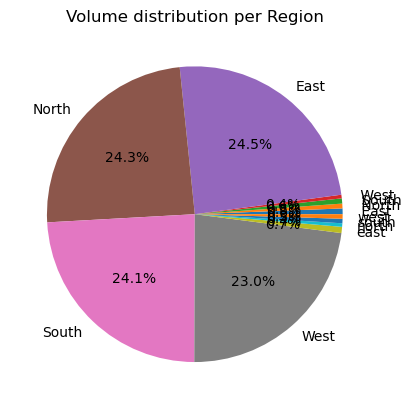

In [93]:
# Solution:
df.groupby('region')['transaction_amount'].sum().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title("Volume distribution per Region")
plt.show()

### Q44: Write code to plot a scatter plot of transaction_amount vs account_age_months.

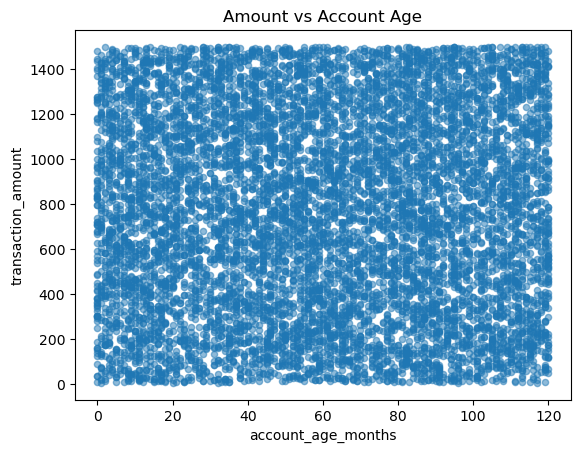

In [94]:
# Solution:
df.plot.scatter(x='account_age_months', y='transaction_amount', alpha=0.5)
plt.title("Amount vs Account Age")
plt.show()

### Q45: Write code to draw a bar chart of average transaction amounts across different regions.

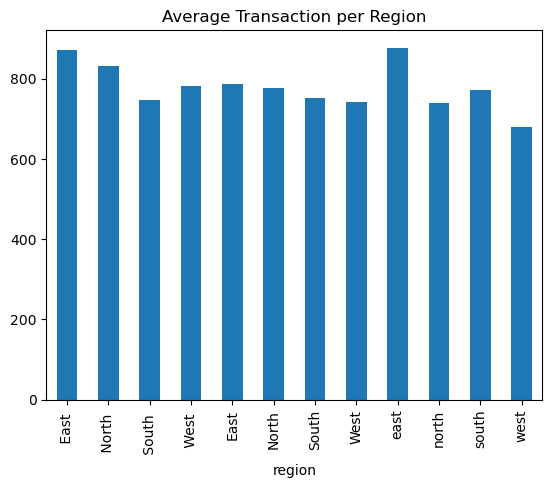

In [95]:
# Solution:
df.groupby('region')['transaction_amount'].mean().plot.bar()
plt.title("Average Transaction per Region")
plt.show()

### Q46: Write code to plot a histogram of transaction amounts with 20 bins.

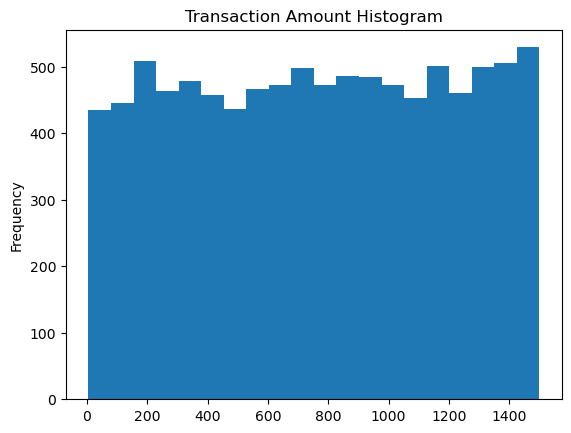

In [96]:
# Solution:
df['transaction_amount'].plot.hist(bins=20)
plt.title("Transaction Amount Histogram")
plt.show()

### Q47: Write code to draw a box plot of transaction amounts to detect extreme high-value outliers.

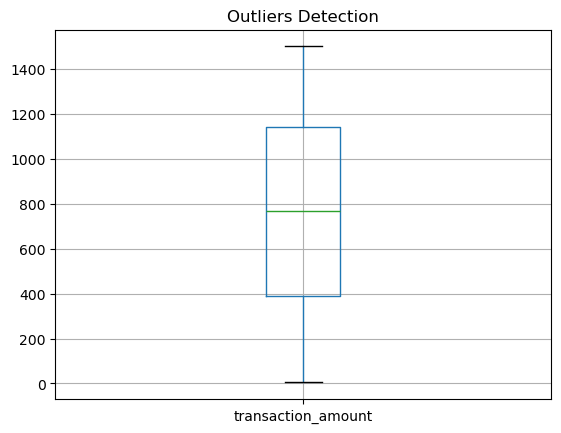

In [97]:
# Solution:
df.boxplot(column='transaction_amount')
plt.title("Outliers Detection")
plt.show()

### Q48: How do you convert the datatype of transaction_id to string and transaction_amount to float32 at once?

In [98]:
# Solution:
df_cast = df.astype({'transaction_id': 'str', 'transaction_amount': 'float32'})
print(df_cast.dtypes)

transaction_id         object
customer_id            object
transaction_amount    float32
account_age_months      uint8
transaction_date       object
region                 object
amount_z_score        float64
dtype: object


### Q49: How do you merge transactions with a mock customer profile table containing customer signup dates?

In [99]:
df_cust_profile = pd.DataFrame({
    'customer_id': df['customer_id'].dropna().unique(),
    'signup_year': np.random.choice([2022, 2023, 2024], size=len(df['customer_id'].dropna().unique()))
})
# Solution:
merged = pd.merge(df, df_cust_profile, on='customer_id', how='left')
print(merged[['customer_id', 'transaction_amount', 'signup_year']].head(5))

  customer_id  transaction_amount  signup_year
0      C54313                 NaN         2023
1      C40161              931.17         2024
2      C91183              932.88         2024
3      C36071              339.48         2024
4      C72296              100.39         2023


### Q50: How do you save our cleaned transactions dataset to an Excel file under the sheet name 'Transactions_2026'?

In [100]:
# Solution:
# df.to_excel('transactions_export.xlsx', sheet_name='Transactions_2026', index=False)
print("Mock: df.to_excel('transactions_export.xlsx', sheet_name='Transactions_2026', index=False)")

Mock: df.to_excel('transactions_export.xlsx', sheet_name='Transactions_2026', index=False)
